# 気象データと電力価格データ

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
import statsmodels
import seaborn

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib" , matplotlib.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("seaborn:", seaborn.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib 3.10.8
scipy: 1.17.1
sklearn: 1.8.0
statsmodels: 0.14.6
seaborn: 0.13.2


### 気象データ
https://dev.meteostat.net/

In [2]:
#!pip install meteostat
!pip show meteostat

Name: meteostat
Version: 2.1.3
Summary: Access and analyze historical weather and climate data with Python.
Home-page: 
Author: Meteostat
Author-email: 
License: 
Location: C:\Users\h20s1\workspace\.venv\Lib\site-packages
Requires: pandas, pytz, requests
Required-by: 


In [3]:
from datetime import date
import meteostat as ms

In [4]:
# tokyo
point_tokyo = ms.Point(35.6895, 139.6917)

start = date(2023, 1, 1)
end = date(2023, 12, 31)

stations = ms.stations.nearby(point_tokyo, limit=4)

ts = ms.daily(stations, start, end)

df_tokyo = ms.interpolate(ts, point_tokyo).fetch()

df_tokyo.head()

,temp,tmin,tmax,rhum,prcp,wspd,pres,cldc
time,,,,,,,,
2023-01-01,6.3,0.9,12.3,64,0.0,6.7,1018.9,0
2023-01-02,6.1,2.3,11.2,52,0.0,8.7,1018.5,3
2023-01-03,5.6,0.7,10.5,44,0.0,8.9,1018.3,2
2023-01-04,5.3,1.2,10.3,48,0.0,10.5,1018.0,2
2023-01-05,5.6,2.3,10.0,38,0.0,13.4,1021.6,1


| 列    | 意味        |
| ---- | --------- |
| temp | 平均気温 (°C) |
| tmin | 最低気温      |
| tmax | 最高気温      |
| rhum | 湿度 (%)    |
| prcp | 降水量 (mm)  |
| wspd | 風速 (km/h) |
| pres | 気圧        |
| cldc | 雲量        |


In [5]:
type(df_tokyo)

pandas.DataFrame

In [6]:
type(df_tokyo["temp"])

pandas.Series

In [7]:
df_tokyo.index

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25',
               '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29',
               '2023-12-30', '2023-12-31'],
              dtype='datetime64[us]', name='time', length=365, freq=None)

In [8]:
# check index data type
type(df_tokyo.index)

pandas.DatetimeIndex

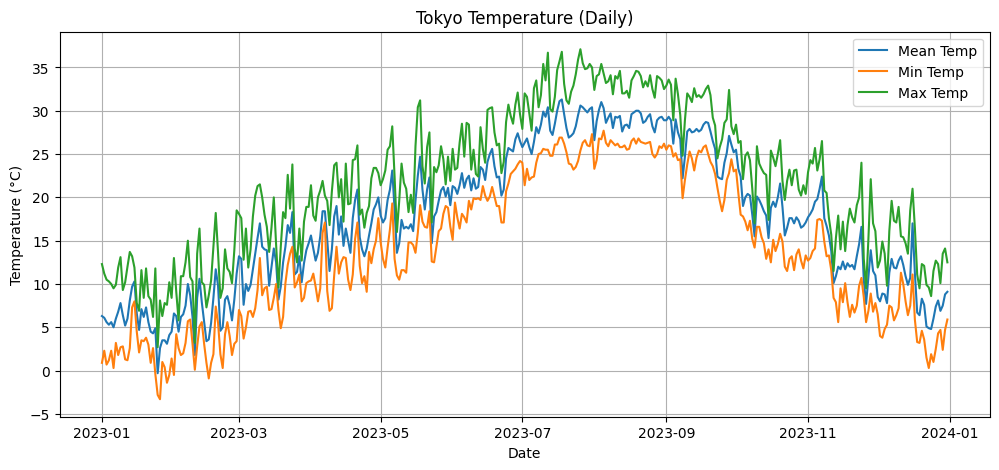

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df_tokyo.index, df_tokyo["temp"], label="Mean Temp")
plt.plot(df_tokyo.index, df_tokyo["tmin"], label="Min Temp")
plt.plot(df_tokyo.index, df_tokyo["tmax"], label="Max Temp")

plt.title("Tokyo Temperature (Daily)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(True)

plt.show()

In [10]:
# hirosaki
point_hirosaki = ms.Point(40.6031, 140.4639)

start = date(2023,1,1)
end = date(2023,12,31)

stations = ms.stations.nearby(point_hirosaki,limit = 1)
ts = ms.daily(stations, start, end)

df_hirosaki = ts.fetch()

df_hirosaki.head()

temp  tmin  tmax  rhum  prcp  snwd  wspd  wpgt    pres  \
station time                                                                 
47542   2023-01-01  -1.0  -4.9   2.0    79   8.7  <NA>  23.4  <NA>  1014.7   
        2023-01-02  -5.4  -6.6  -4.7    84  11.4  <NA>  25.5  <NA>  1014.6   
        2023-01-03  -5.2  -6.7  -4.0    87   7.2  <NA>  24.8  <NA>  1013.7   
        2023-01-04  -5.1  -6.7  -4.0    86   6.2  <NA>  22.1  <NA>  1014.0   
        2023-01-05  -3.5  -6.6  -1.0    79   2.0  <NA>  19.1  <NA>  1017.6   

                    tsun  cldc  
station time                    
47542   2023-01-01  <NA>     6  
        2023-01-02  <NA>     8  
        2023-01-03  <NA>     7  
        2023-01-04  <NA>     7  
        2023-01-05  <NA>     7

In [11]:
df_hirosaki = df_hirosaki.reset_index()
df_hirosaki = df_hirosaki.drop(columns="station")
df_hirosaki = df_hirosaki.set_index("time")

In [12]:
df_hirosaki.head()

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
time,,,,,,,,,,,
2023-01-01,-1.0,-4.9,2.0,79,8.7,<NA>,23.4,<NA>,1014.7,<NA>,6
2023-01-02,-5.4,-6.6,-4.7,84,11.4,<NA>,25.5,<NA>,1014.6,<NA>,8
2023-01-03,-5.2,-6.7,-4.0,87,7.2,<NA>,24.8,<NA>,1013.7,<NA>,7
2023-01-04,-5.1,-6.7,-4.0,86,6.2,<NA>,22.1,<NA>,1014.0,<NA>,7
2023-01-05,-3.5,-6.6,-1.0,79,2.0,<NA>,19.1,<NA>,1017.6,<NA>,7


In [13]:
type(df_hirosaki)

pandas.DataFrame

In [14]:
type(df_hirosaki["temp"])

pandas.Series

In [15]:
type(df_hirosaki.index)

pandas.DatetimeIndex

In [16]:
print(df_hirosaki.index)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25',
               '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29',
               '2023-12-30', '2023-12-31'],
              dtype='datetime64[us]', name='time', length=365, freq=None)


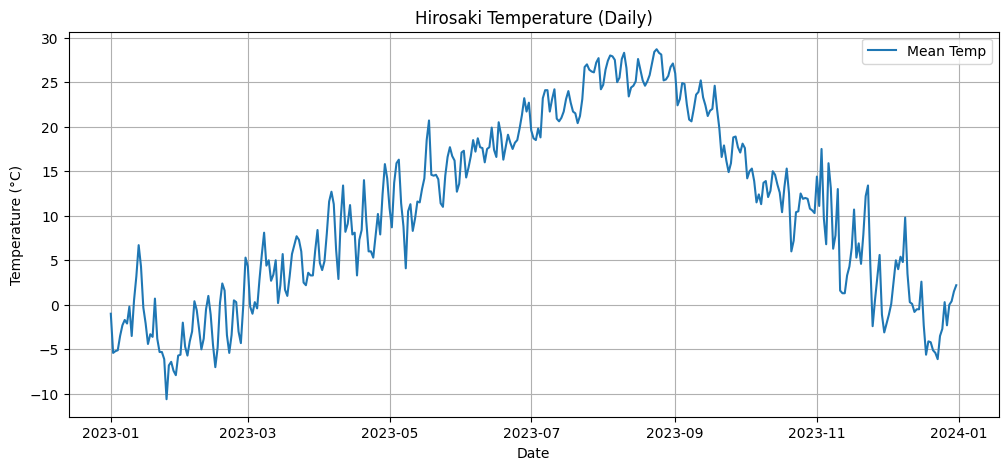

In [17]:
plt.figure(figsize=(12,5))

plt.plot(df_hirosaki.index, df_hirosaki["temp"], label="Mean Temp")

plt.title("Hirosaki Temperature (Daily)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
df_tokyo.head()

,temp,tmin,tmax,rhum,prcp,wspd,pres,cldc
time,,,,,,,,
2023-01-01,6.3,0.9,12.3,64,0.0,6.7,1018.9,0
2023-01-02,6.1,2.3,11.2,52,0.0,8.7,1018.5,3
2023-01-03,5.6,0.7,10.5,44,0.0,8.9,1018.3,2
2023-01-04,5.3,1.2,10.3,48,0.0,10.5,1018.0,2
2023-01-05,5.6,2.3,10.0,38,0.0,13.4,1021.6,1


In [19]:
df_hirosaki.head()

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,tsun,cldc
time,,,,,,,,,,,
2023-01-01,-1.0,-4.9,2.0,79,8.7,<NA>,23.4,<NA>,1014.7,<NA>,6
2023-01-02,-5.4,-6.6,-4.7,84,11.4,<NA>,25.5,<NA>,1014.6,<NA>,8
2023-01-03,-5.2,-6.7,-4.0,87,7.2,<NA>,24.8,<NA>,1013.7,<NA>,7
2023-01-04,-5.1,-6.7,-4.0,86,6.2,<NA>,22.1,<NA>,1014.0,<NA>,7
2023-01-05,-3.5,-6.6,-1.0,79,2.0,<NA>,19.1,<NA>,1017.6,<NA>,7


In [20]:
## make 2-d dataset
# take out tempdata
tokyo_temp = df_tokyo["temp"].rename("tokyo_temp")
hirosaki_temp = df_hirosaki["temp"].rename("hirosaki_temp")

df_weather = pd.concat([tokyo_temp, hirosaki_temp], axis=1)
df_weather

,tokyo_temp,hirosaki_temp
time,,
2023-01-01,6.3,-1.0
2023-01-02,6.1,-5.4
2023-01-03,5.6,-5.2
2023-01-04,5.3,-5.1
2023-01-05,5.6,-3.5
...,...,...
2023-12-27,8.1,-2.3
2023-12-28,6.9,0.0
2023-12-29,7.5,0.4


In [21]:
len(df_weather)

365

In [22]:
df_weather.isna().sum()

tokyo_temp       0
hirosaki_temp    0
dtype: int64

In [23]:
#df_weather = df_weather.dropna()

In [24]:
type(df_weather)

pandas.DataFrame

In [25]:
type(df_weather.index)

pandas.DatetimeIndex

In [26]:
df_weather.index.dtype

dtype('<M8[us]')

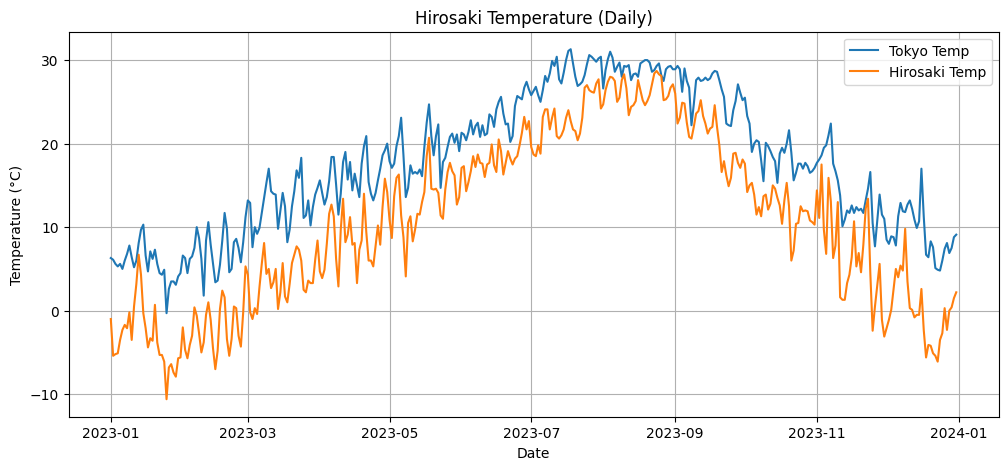

In [27]:
plt.figure(figsize=(12,5))

plt.plot(df_weather.index, df_weather["tokyo_temp"], label="Tokyo Temp")
plt.plot(df_weather.index, df_weather["hirosaki_temp"], label="Hirosaki Temp")

plt.title("Hirosaki Temperature (Daily)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(True)

plt.show()

### 電力価格データ
https://www.jepx.jp/electricpower/market-data/spot/

In [28]:
from pathlib import Path
csv_path = Path("../data/raw/spot_summary_2023.csv")

df_price = pd.read_csv(csv_path, encoding="cp932")

df_price.head()

,受渡日,時刻コード,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh)
0,2023/04/01,1,17694200,15655300,13346500,10.48,16.53,14.68,14.68,14.68,5.84,5.84,5.84,5.84,5.84,4992400,1315100,1037200,715100
1,2023/04/01,2,19404500,15901400,13408300,10.41,13.99,13.99,13.99,13.99,9.40,9.40,9.40,9.40,9.40,5963350,1315450,1556650,992250
2,2023/04/01,3,20293600,15947500,13455550,10.42,11.83,11.83,11.83,11.83,10.13,10.13,10.13,10.13,10.13,6366250,1315750,1830950,1266250
3,2023/04/01,4,20808400,15830300,13461450,10.37,11.08,11.08,11.08,11.08,10.13,10.13,10.13,10.13,10.13,6659450,1315950,2054200,1489400
4,2023/04/01,5,20885350,15821750,13508900,10.35,11.02,11.02,11.02,11.02,10.00,10.00,10.00,10.00,5.84,6530500,1316100,2097150,1532200


In [29]:
type(df_price.index)

pandas.RangeIndex

In [30]:
type(df_price["受渡日"])

pandas.Series

In [31]:
df_price["受渡日"].dtype

<StringDtype(storage='python', na_value=nan)>


重要なデータ
| 列         | 意味      |
| --------- | ------- |
| 受渡日       | 取引日     |
| 時刻コード     | 30分スロット |
| システムプライス  | 全国共通価格  |
| エリアプライス東京 | 東京エリア価格 |

このデータについてはいくつか問題点があるので整理したい
- indexデータ型が文字列
- データが30分前になっている

特に30分→1日ごとにする際の変換方式が重要になっていく。今回は単純な平均と最大値、最小値、そして日内ボラティリティとする

- 最大値→スパイク検出
- 最小値→需供余剰
- 日内ボラ→市場不安定性 

In [32]:
df_price["受渡日"] = pd.to_datetime(df_price["受渡日"])
df_price["受渡日"].dtype

dtype('<M8[us]')

In [33]:
df_price["datetime"] = (
    df_price["受渡日"]
    + pd.to_timedelta((df_price["時刻コード"] - 1) * 30, unit="m")
)

In [34]:
df_price["datetime"]

0       2023-04-01 00:00:00
1       2023-04-01 00:30:00
2       2023-04-01 01:00:00
3       2023-04-01 01:30:00
4       2023-04-01 02:00:00
                ...        
17563   2024-03-31 21:30:00
17564   2024-03-31 22:00:00
17565   2024-03-31 22:30:00
17566   2024-03-31 23:00:00
17567   2024-03-31 23:30:00
Name: datetime, Length: 17568, dtype: datetime64[us]

In [35]:
df_price = df_price.set_index("datetime")

In [36]:
df_price = df_price.drop(["受渡日","時刻コード"], axis=1)
df_price

,売り入札量(kWh),買い入札量(kWh),約定総量(kWh),システムプライス(円/kWh),エリアプライス北海道(円/kWh),エリアプライス東北(円/kWh),エリアプライス東京(円/kWh),エリアプライス中部(円/kWh),エリアプライス北陸(円/kWh),エリアプライス関西(円/kWh),エリアプライス中国(円/kWh),エリアプライス四国(円/kWh),エリアプライス九州(円/kWh),売りブロック入札総量(kWh),売りブロック約定総量(kWh),買いブロック入札総量(kWh),買いブロック約定総量(kWh)
datetime,,,,,,,,,,,,,,,,,
2023-04-01 00:00:00,17694200,15655300,13346500,10.48,16.53,14.68,14.68,14.68,5.84,5.84,5.84,5.84,5.84,4992400,1315100,1037200,715100
2023-04-01 00:30:00,19404500,15901400,13408300,10.41,13.99,13.99,13.99,13.99,9.40,9.40,9.40,9.40,9.40,5963350,1315450,1556650,992250
2023-04-01 01:00:00,20293600,15947500,13455550,10.42,11.83,11.83,11.83,11.83,10.13,10.13,10.13,10.13,10.13,6366250,1315750,1830950,1266250
2023-04-01 01:30:00,20808400,15830300,13461450,10.37,11.08,11.08,11.08,11.08,10.13,10.13,10.13,10.13,10.13,6659450,1315950,2054200,1489400
2023-04-01 02:00:00,20885350,15821750,13508900,10.35,11.02,11.02,11.02,11.02,10.00,10.00,10.00,10.00,5.84,6530500,1316100,2097150,1532200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-03-31 21:30:00,26114150,15363800,11962000,10.00,12.35,12.35,12.35,9.94,9.59,9.59,9.59,9.59,9.59,12589550,596000,2001550,1451550
2024-03-31 22:00:00,25910600,14917850,11649800,9.82,12.09,12.09,12.09,10.00,9.50,9.50,9.50,9.50,9.50,12172600,595800,1899200,1449200
2024-03-31 22:30:00,26144600,14238600,11446750,9.25,9.50,9.50,9.50,9.35,9.35,9.35,9.35,9.35,9.35,12052950,595850,1728200,1378200


In [37]:
tokyo_price = df_price[["エリアプライス東京(円/kWh)"]]
tokyo_price = tokyo_price.rename(columns={"エリアプライス東京(円/kWh)": "tokyo_price"})
tokyo_price

,tokyo_price
datetime,
2023-04-01 00:00:00,14.68
2023-04-01 00:30:00,13.99
2023-04-01 01:00:00,11.83
2023-04-01 01:30:00,11.08
2023-04-01 02:00:00,11.02
...,...
2024-03-31 21:30:00,12.35
2024-03-31 22:00:00,12.09
2024-03-31 22:30:00,9.50


In [38]:
price_aug_oct = tokyo_price.loc["2023-08-01":"2023-10-31"]

In [39]:
type(tokyo_price)

pandas.DataFrame

In [40]:
tokyo_price.index

DatetimeIndex(['2023-04-01 00:00:00', '2023-04-01 00:30:00',
               '2023-04-01 01:00:00', '2023-04-01 01:30:00',
               '2023-04-01 02:00:00', '2023-04-01 02:30:00',
               '2023-04-01 03:00:00', '2023-04-01 03:30:00',
               '2023-04-01 04:00:00', '2023-04-01 04:30:00',
               ...
               '2024-03-31 19:00:00', '2024-03-31 19:30:00',
               '2024-03-31 20:00:00', '2024-03-31 20:30:00',
               '2024-03-31 21:00:00', '2024-03-31 21:30:00',
               '2024-03-31 22:00:00', '2024-03-31 22:30:00',
               '2024-03-31 23:00:00', '2024-03-31 23:30:00'],
              dtype='datetime64[us]', name='datetime', length=17568, freq=None)

<Figure size 1200x400 with 0 Axes>

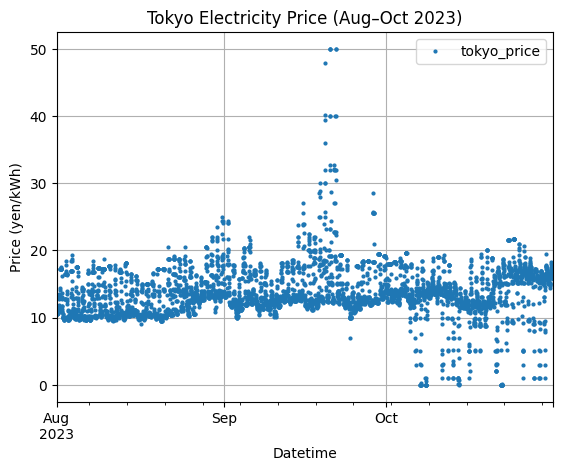

In [41]:
plt.figure(figsize=(12,4))

price_aug_oct.plot(
    marker="o",
    linestyle="None",
    markersize=2
)

plt.title("Tokyo Electricity Price (Aug–Oct 2023)")
plt.ylabel("Price (yen/kWh)")
plt.xlabel("Datetime")

plt.grid(True)

plt.show()

In [42]:
df_price_daily = tokyo_price["tokyo_price"].resample("D").agg(
    price_mean="mean",
    price_max="max",
    price_min="min",
    price_vol="std"
)

In [43]:
df_price_daily.head()

,price_mean,price_max,price_min,price_vol
datetime,,,,
2023-04-01,8.814583,14.82,0.01,6.284523
2023-04-02,8.931875,14.65,0.01,6.139527
2023-04-03,10.700833,15.10,0.01,4.293512
2023-04-04,9.071667,14.58,0.01,5.287413
2023-04-05,12.553125,15.00,10.00,1.816121


In [44]:
df_price_daily.describe()

,price_mean,price_max,price_min,price_vol
count,366.000000,366.000000,366.000000,366.000000
mean,12.202522,17.146503,7.553716,2.836378
std,2.572230,4.500912,4.280629,1.502279
min,5.478958,10.500000,0.010000,0.534722
25%,10.171250,14.642500,5.000000,1.834981
50%,11.988542,16.390000,8.665000,2.493072
75%,14.021875,18.657500,10.440000,3.440208
max,20.764583,50.000000,15.270000,10.380938


In [45]:
# アプリ開発ならばこのくらいは確認すべし
# 1. 型確認
print("====data type===")
print(tokyo_price.dtypes)

# 2. 重複確認
print("====duplication===")
print("duplicated index:", tokyo_price.index.duplicated().sum())

# 3. 1日あたり件数確認
print("===number check===")
daily_count = tokyo_price["tokyo_price"].resample("D").count()
print(daily_count.value_counts().sort_index())

# 4. 期間確認
print("===period===")
print("weather :", df_weather.index.min(), "->", df_weather.index.max())
print("price   :", tokyo_price.index.min(), "->", tokyo_price.index.max())

# 5. 結合後の欠損確認
print("====NaN check==")
df_analysis = pd.concat([df_weather, tokyo_price], axis=1)
df_analysis = df_analysis.dropna()
print(df_analysis.isna().sum())

====data type===
tokyo_price    float64
dtype: object
====duplication===
duplicated index: 0
===number check===
tokyo_price
48    366
Name: count, dtype: int64
===period===
weather : 2023-01-01 00:00:00 -> 2023-12-31 00:00:00
price   : 2023-04-01 00:00:00 -> 2024-03-31 23:30:00
====NaN check==
tokyo_temp       0
hirosaki_temp    0
tokyo_price      0
dtype: int64


C:\Users\h20s1\AppData\Local\Temp\ipykernel_2504\478026893.py:22: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  df_analysis = pd.concat([df_weather, tokyo_price], axis=1)


In [46]:
df_analysis

,tokyo_temp,hirosaki_temp,tokyo_price
2023-04-01,15.6,4.7,14.68
2023-04-02,14.1,3.9,14.65
2023-04-03,12.7,4.9,10.99
2023-04-04,13.6,8.0,14.22
2023-04-05,15.5,11.6,10.96
...,...,...,...
2023-12-27,8.1,-2.3,10.00
2023-12-28,6.9,0.0,11.29
2023-12-29,7.5,0.4,12.17
2023-12-30,8.8,1.5,10.82


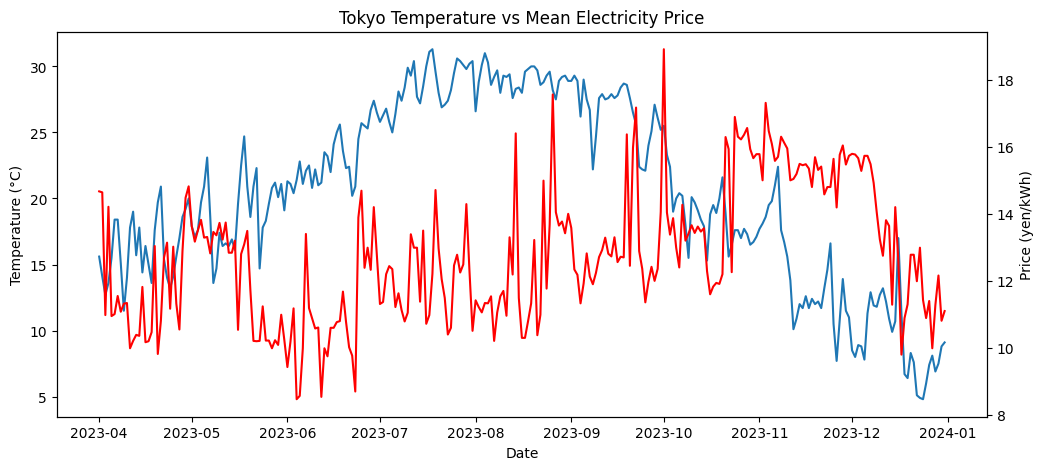

In [47]:
fig, ax1 = plt.subplots(figsize=(12,5))

# 東京気温
ax1.plot(df_analysis.index, df_analysis["tokyo_temp"], label="Tokyo Temp")
ax1.set_ylabel("Temperature (°C)")
ax1.set_xlabel("Date")

# 右軸
ax2 = ax1.twinx()

# 東京平均価格
ax2.plot(df_analysis.index, df_analysis["tokyo_price"], label="Tokyo Price Mean" , color ="red")
ax2.set_ylabel("Price (yen/kWh)")

plt.title("Tokyo Temperature vs Mean Electricity Price")

plt.show()

以下`df_analysis`を用いて共分散関数を学ぶ

# 理論編
## 定常
### 強定常（Strict Stationarity）

確率過程

$$
\{X_t\}_{t \in \mathbb{Z}}
$$

が **強定常（strictly stationary）**であるとは、任意の

- 時点 $t_1,\dots,t_n$
- 任意の時間シフト $h$

について

$$
(X_{t_1}, X_{t_2}, \dots, X_{t_n})
\overset{d}{=}
(X_{t_1+h}, X_{t_2+h}, \dots, X_{t_n+h})
$$

が成り立つことである。

ここで

$$
\overset{d}{=}
$$

は **同じ確率分布を持つ**ことを意味する。

つまり

時間を平行移動しても **確率分布が完全に同じ**である。

### 弱定常（Weak Stationarity）

確率過程

$$
\{X_t\}
$$

が **弱定常（weakly stationary）**であるとは、次の3条件を満たすことである。

#### 平均が一定

$$
E[X_t] = \mu
$$

#### 分散が一定

$$
Var(X_t) = \sigma^2 < \infty
$$

#### 共分散がラグのみに依存

$$
Cov(X_t, X_{t+h}) = \gamma(h)
$$

つまり

共分散は **時間 $t$ ではなくラグ $h$ のみで決まる**。

---

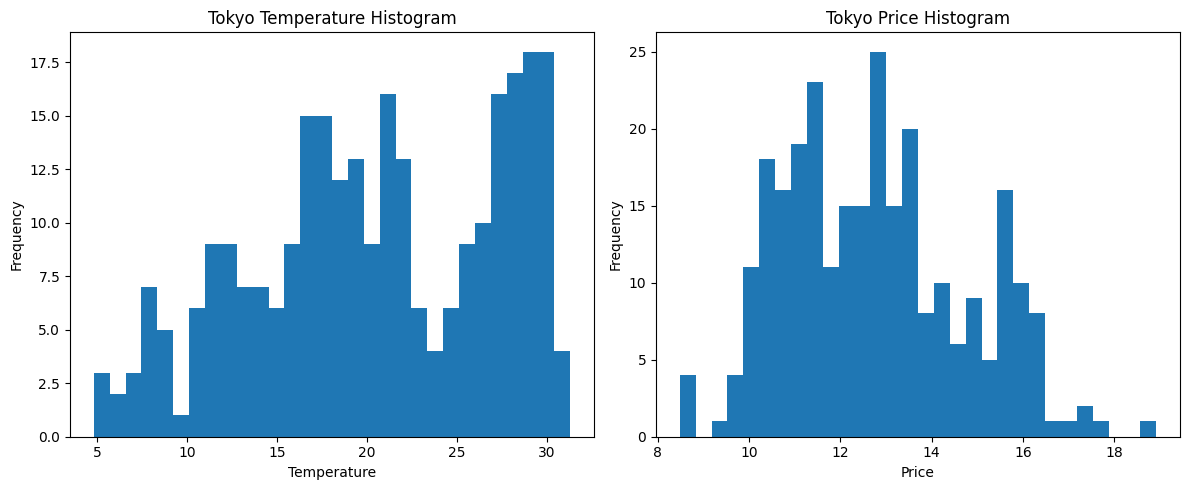

In [48]:
# hist
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df_analysis["tokyo_temp"], bins=30)
plt.title("Tokyo Temperature Histogram")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(df_analysis["tokyo_price"], bins=30)
plt.title("Tokyo Price Histogram")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

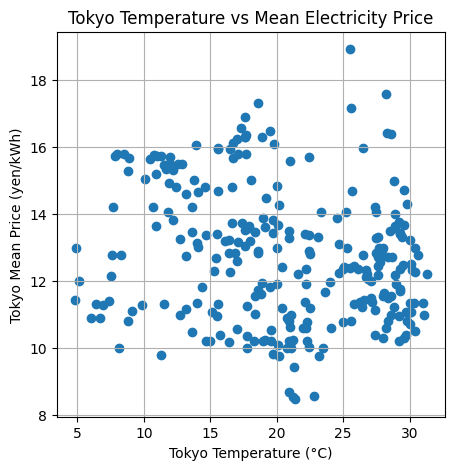

In [49]:
# scatter
plt.figure(figsize=(5,5))
plt.scatter(
    df_analysis["tokyo_temp"],
    df_analysis["tokyo_price"]
)
plt.xlabel("Tokyo Temperature (°C)")
plt.ylabel("Tokyo Mean Price (yen/kWh)")
plt.title("Tokyo Temperature vs Mean Electricity Price")
plt.grid(True)

plt.show()

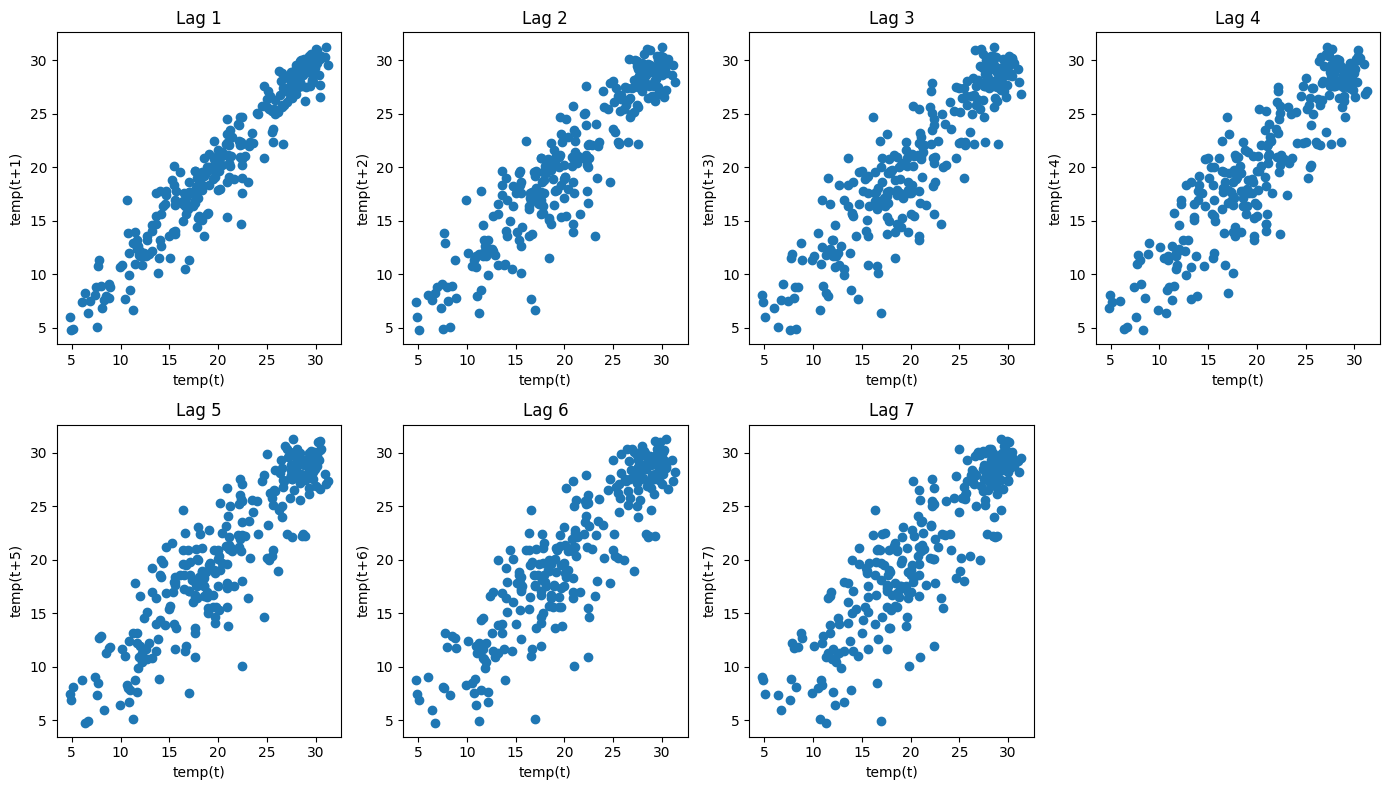

In [50]:
# lag scatter
temp = df_analysis["tokyo_temp"]

plt.figure(figsize=(14,8))

for lag in range(1,8):
    
    plt.subplot(2,4,lag)
    
    plt.scatter(
        temp[:-lag],
        temp[lag:]
    )
    
    plt.xlabel(f"temp(t)")
    plt.ylabel(f"temp(t+{lag})")
    plt.title(f"Lag {lag}")

plt.tight_layout()
plt.show()

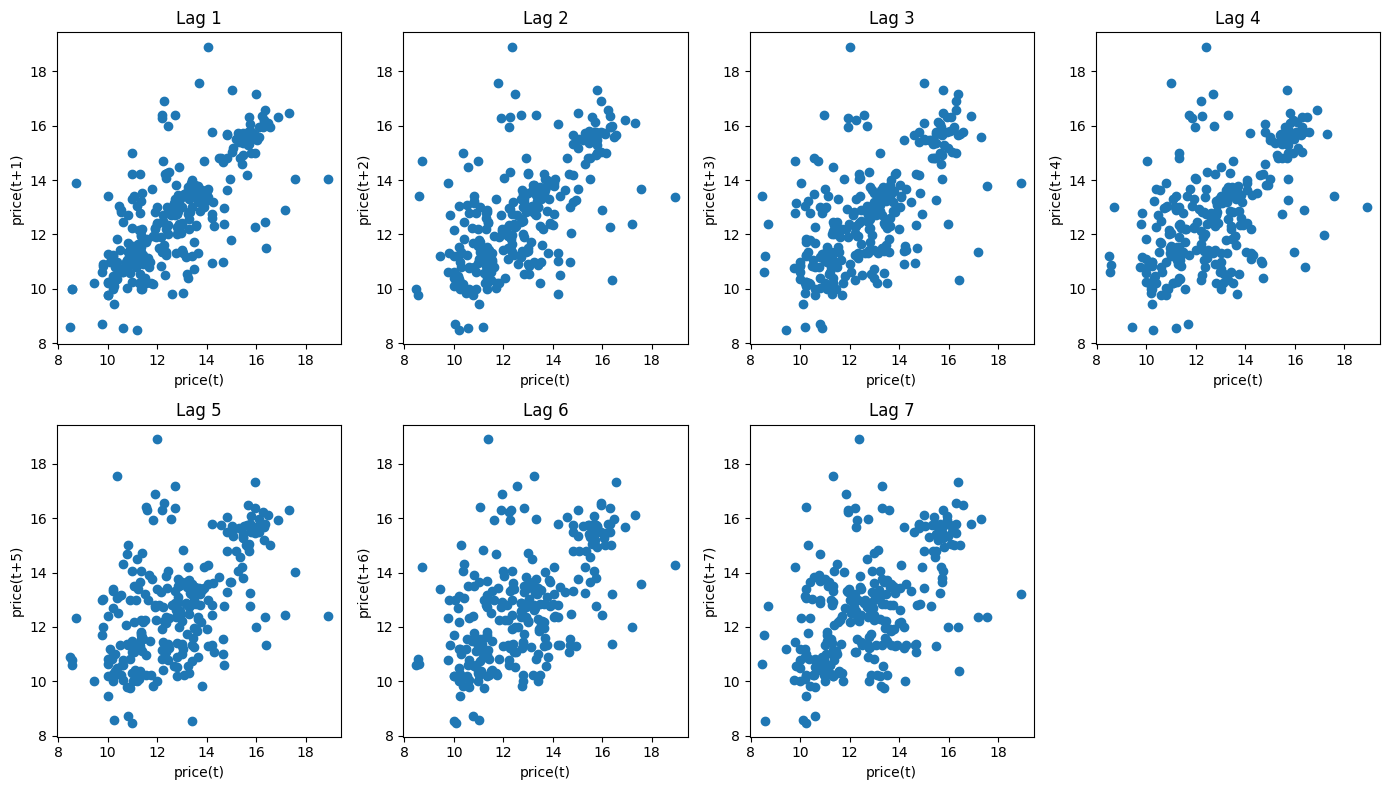

In [51]:
# lag scatter
price = df_analysis["tokyo_price"]

plt.figure(figsize=(14,8))

for lag in range(1,8):
    
    plt.subplot(2,4,lag)
    
    plt.scatter(
        price[:-lag],
        price[lag:]
    )
    
    plt.xlabel(f"price(t)")
    plt.ylabel(f"price(t+{lag})")
    plt.title(f"Lag {lag}")

plt.tight_layout()
plt.show()

## 自己共分散関数
弱定常過程では

$$
\gamma(h) = Cov(X_t, X_{t+h})
$$

で定義される。

展開すると

$$
\gamma(h)
=
E[(X_t-\mu)(X_{t+h}-\mu)]
$$

である。

## 自己相関関数（Autocorrelation Function）

自己相関関数は

$$
\rho(h)
=
\frac{\gamma(h)}{\gamma(0)}
$$

で定義される。

ここで

$$
\gamma(0)=Var(X_t)
$$

である。

したがって

$$
-1 \le \rho(h) \le 1
$$

が成り立つ。

<Figure size 640x480 with 0 Axes>

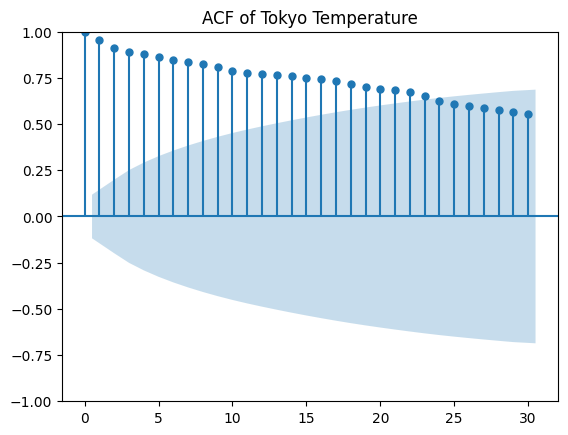

In [52]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure()

plot_acf(
    df_analysis["tokyo_temp"],
    lags=30
)

plt.title("ACF of Tokyo Temperature")

plt.show()

<Figure size 640x480 with 0 Axes>

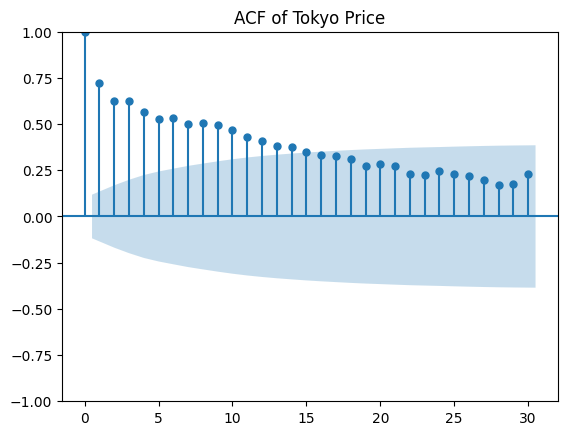

In [53]:
plt.figure()

plot_acf(
    df_analysis["tokyo_price"],
    lags=30
)

plt.title("ACF of Tokyo Price")

plt.show()

弱定常確認の流れ

1.プロット
| ポイント | 意味  |
| ---- | --- |
| トレンド | 非定常 |
| 分散変化 | 非定常 |
| 周期   | 季節性 |


<Axes: >

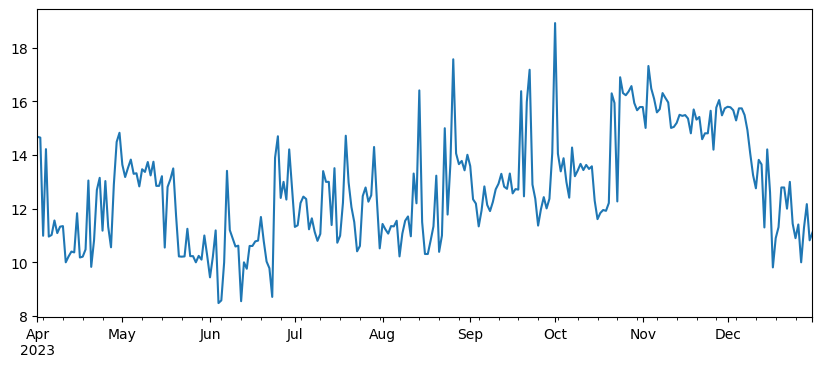

In [54]:
df_analysis["tokyo_price"].plot(figsize=(10,4))

2.移動平均と移動分散

変動がないこと

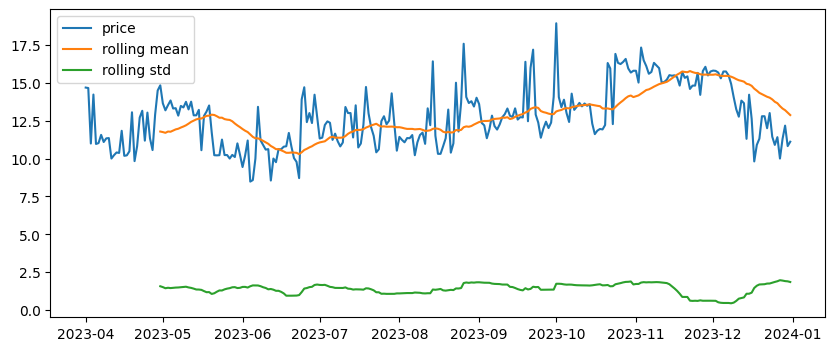

In [55]:
rolling_mean = df_analysis["tokyo_price"].rolling(30).mean()
rolling_std = df_analysis["tokyo_price"].rolling(30).std()

plt.figure(figsize=(10,4))
plt.plot(df_analysis["tokyo_price"], label="price")
plt.plot(rolling_mean, label="rolling mean")
plt.plot(rolling_std, label="rolling std")

plt.legend()
plt.show()

3.統計的検定

In [56]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_analysis["tokyo_price"])

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -3.5387019700532
p-value: 0.007047029952989441


## 相互共分散関数 (Cross Covariance Function)

$ℓ$次元の多変量時系列

$$
y_n = (y_n(1),\dots,y_n(\ell))^T
$$

を考える。

まず，各成分の平均は

$$
\mu(i) = E[y_n(i)]
$$

で定義される。

平均ベクトルは

$$
\mu = (\mu(1),\dots,\mu(\ell))^T
$$

である。

### 相互共分散

時系列 \(y_n(i)\) と \(y_{n-k}(j)\) の共分散は

$$
C_k(i,j)
=
\mathrm{Cov}(y_n(i),y_{n-k}(j))
$$

$$
=
E[(y_n(i)-\mu(i))(y_{n-k}(j)-\mu(j))^T]
$$

で定義される。

### 相互共分散行列

このとき

$$
C_k =
\begin{bmatrix}
C_k(1,1) & \cdots & C_k(1,\ell) \\
\vdots & \ddots & \vdots \\
C_k(\ell,1) & \cdots & C_k(\ell,\ell)
\end{bmatrix}
$$

は **ラグ \(k\) の相互共分散行列** と呼ばれる。

### 相互共分散関数

$$
\{C_k\}, \quad k = 0,1,2,\dots
$$

を **相互共分散関数 (cross-covariance function)** という。

### 相互相関行列

相互相関係数を並べた

$$
R_k =
\begin{bmatrix}
R_k(1,1) & \cdots & R_k(1,\ell) \\
\vdots & \ddots & \vdots \\
R_k(\ell,1) & \cdots & R_k(\ell,\ell)
\end{bmatrix}
$$

を **ラグ $k$ の相互相関行列** という。

### 相互相関関数

$$
\{R_k\}, \quad k = 0,1,2,\dots
$$

を **相互相関関数 (cross-correlation function)** という。

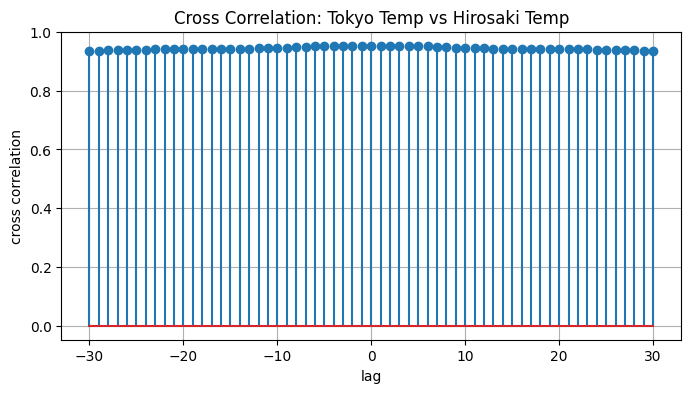

In [57]:
tokyo = df_analysis["tokyo_temp"]
hirosaki = df_analysis["hirosaki_temp"]

max_lag = 30
lags = range(-max_lag, max_lag+1)

ccf = []

for k in lags:

    if k < 0:
        corr = tokyo[:k].corr(hirosaki[-k:])
    elif k > 0:
        corr = tokyo[k:].corr(hirosaki[:-k])
    else:
        corr = tokyo.corr(hirosaki)

    ccf.append(corr)


plt.figure(figsize=(8,4))
plt.stem(lags, ccf)

plt.xlabel("lag")
plt.ylabel("cross correlation")
plt.title("Cross Correlation: Tokyo Temp vs Hirosaki Temp")

plt.grid(True)
plt.show()

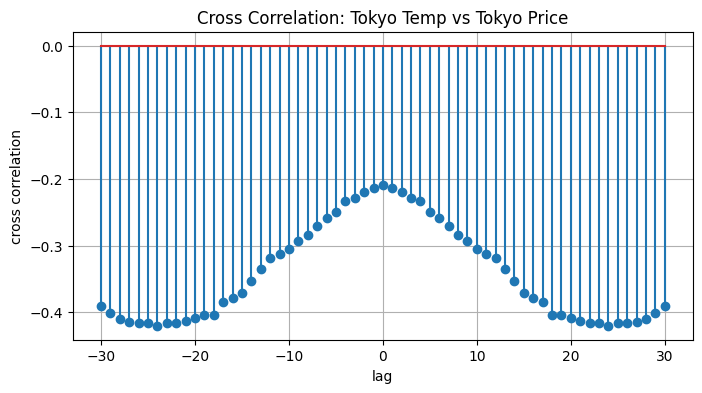

In [58]:
temp = df_analysis["tokyo_temp"]
price = df_analysis["tokyo_price"]

max_lag = 30
lags = range(-max_lag, max_lag+1)

ccf = []

for k in lags:

    if k < 0:
        corr = temp[:k].corr(price[-k:])
        
    elif k > 0:
        corr = temp[k:].corr(price[:-k])
        
    else:
        corr = temp.corr(price)

    ccf.append(corr)


plt.figure(figsize=(8,4))
plt.stem(lags, ccf)

plt.xlabel("lag")
plt.ylabel("cross correlation")
plt.title("Cross Correlation: Tokyo Temp vs Tokyo Price")

plt.grid(True)
plt.show()

差分をとってもう一度

In [59]:
df_analysis["temp_diff"] = df_analysis["tokyo_temp"].diff()
df_analysis["price_diff"] = df_analysis["tokyo_price"].diff()

In [60]:
df_diff = df_analysis[["temp_diff","price_diff"]].dropna()

In [61]:
temp = df_diff["temp_diff"]
price = df_diff["price_diff"]

max_lag = 30
lags = range(-max_lag, max_lag+1)

cross_cov = []

for k in lags:

    if k < 0:
        cov = ((temp[:k] - temp.mean()) *
               (price[-k:] - price.mean())).mean()
        
    elif k > 0:
        cov = ((temp[k:] - temp.mean()) *
               (price[:-k] - price.mean())).mean()
        
    else:
        cov = ((temp - temp.mean()) *
               (price - price.mean())).mean()

    cross_cov.append(cov)

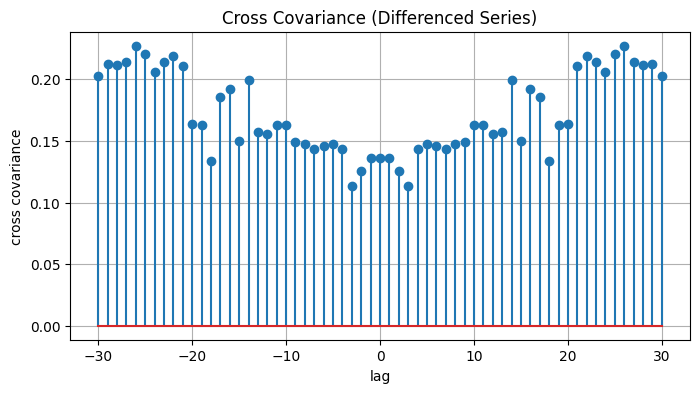

In [62]:
plt.figure(figsize=(8,4))

plt.stem(lags, cross_cov)

plt.xlabel("lag")
plt.ylabel("cross covariance")
plt.title("Cross Covariance (Differenced Series)")

plt.grid(True)

plt.show()

# データセット作成